# Implementation of Generative Forecasting using Joint Probability Models on KS PDE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg
import sys
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim

In [2]:
dataset = np.load("/kaggle/input/datasets/theredatom/ks-1d-pde/ks_dataset_imex.npy")

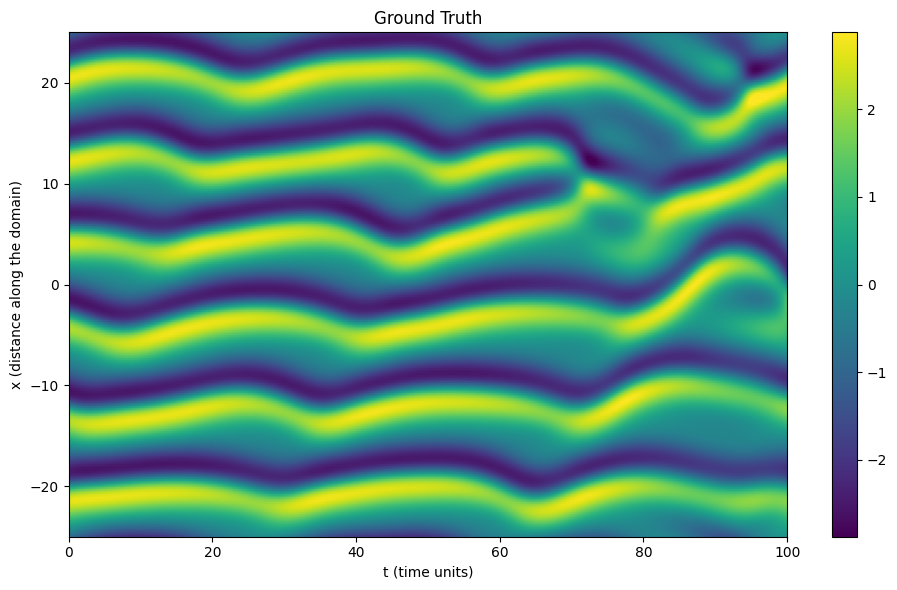

In [3]:
data_slice=dataset[int(1e6):int(1e6)+1000:]
plot_data=data_slice.T

dt=0.1
x_min,x_max=-25,25

t_start = 0
t_end = data_slice.shape[0] * dt 

plt.figure(figsize=(10,6))
plt.imshow(plot_data,
           aspect='auto',
           origin='lower',
           extent=[t_start,t_end,x_min,x_max],
           cmap='viridis',
           vmin=-2.88,
           vmax=2.88)

plt.title("Ground Truth")
plt.xlabel("t (time units)")
plt.ylabel("x (distance along the domain)")
plt.xticks([0, 20, 40, 60, 80, 100])
plt.tight_layout()
plt.colorbar()
plt.show()

In [4]:
dataset.shape

(4000000, 200)

In [5]:
class JointWindowDataset(Dataset):
    def __init__(self, trajectory, n=2, num_windows=1_000_000):
        self.trajectory = trajectory
        self.n = n
        self.num_windows = min(num_windows, len(trajectory) - n + 1)
        
        mean_per_trajectory = trajectory[:self.num_windows+(n-1)].mean(axis=0).astype(np.float32)
        std_per_trajectory = trajectory[:self.num_windows+(n-1)].std(axis=0).astype(np.float32)
        
        self.mean = np.tile(mean_per_trajectory,self.n)
        self.std = np.tile(std_per_trajectory,self.n) + 1e-8

    def __len__(self):
        return self.num_windows

    def __getitem__(self, idx):
        window = self.trajectory[idx:idx+self.n].reshape(-1)
        window = window.astype(np.float32)
        window = (window - self.mean) / self.std
        return torch.from_numpy(window)
        

In [6]:
train_dataset = JointWindowDataset(dataset, n=2, num_windows=1_000_000)

In [7]:
train_dataloader = DataLoader(train_dataset,batch_size=2000,shuffle=True,num_workers=4)

In [8]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 1000000


In [9]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 400, hidden_dim = 1500):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.01)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.01)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]
            log_sigma_i = torch.clamp(log_sigma_i, min=-5, max=2)
            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1, device=mu_i.device)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence


    def sample_batch(self,batch_size):
        device=self.c.device

        generated=torch.zeros(batch_size,self.input_dim,device=device)
        a_i=self.c.unsqueeze(0).repeat(batch_size,1)

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i=torch.relu(a_i)

                mu_i=h_i@self.V_mu[i]+self.b_mu[i]
                log_sigma_i=h_i@self.V_log_sigma[i]+self.b_log_sigma[i]
                log_sigma_i=torch.clamp(log_sigma_i,min=-5,max=2)

                sigma_i=torch.exp(log_sigma_i)

                sampled_values=mu_i+sigma_i*torch.randn(batch_size,device=device)

                generated[:,i]=sampled_values

                if i<self.input_dim-1:
                    a_i=a_i+sampled_values.unsqueeze(1)*self.W[:,i].unsqueeze(0)

        return generated

In [10]:
def gaussian_nll_loss(mu, log_sigma, target):
    variance = torch.exp(log_sigma) ** 2
    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    #Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE()

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model, device_ids=[0, 1])
    
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4) 
train_loss_history = []
epochs = 80
best_loss = float("inf")
save_path = "best_continuous_nade.pt"                      

# Simple Training Loop
for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.float().to(device)
        optimizer.zero_grad()
        mu_outputs, log_sigma_outputs = model(batch)
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    train_loss_history.append(avg_loss)

    if avg_loss < best_loss:
        best_loss = avg_loss
        
        if isinstance(model, nn.DataParallel):
            model_state = model.module.state_dict()
        else:
            model_state = model.state_dict()
            
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "best_loss": best_loss,
            "train_loss_history": train_loss_history
        }, save_path)
        print(f"Saved best model at epoch {epoch+1} | Loss: {best_loss:.4f}")
    if (epoch+1)%5 == 0:
        print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')

Saved best model at epoch 1 | Loss: -104.3793
Saved best model at epoch 2 | Loss: -502.1764
Saved best model at epoch 3 | Loss: -661.1990
Saved best model at epoch 4 | Loss: -762.5097
Saved best model at epoch 5 | Loss: -829.3138
Epoch 5/80 | Avg Train Loss: -829.3138
Saved best model at epoch 6 | Loss: -878.4420
Saved best model at epoch 7 | Loss: -917.1691
Saved best model at epoch 8 | Loss: -948.6305
Saved best model at epoch 9 | Loss: -976.1777
Saved best model at epoch 10 | Loss: -1001.1188
Epoch 10/80 | Avg Train Loss: -1001.1188
Saved best model at epoch 11 | Loss: -1023.9737
Saved best model at epoch 12 | Loss: -1045.4102
Saved best model at epoch 13 | Loss: -1065.6689
Saved best model at epoch 14 | Loss: -1084.9266
Saved best model at epoch 15 | Loss: -1103.9904
Epoch 15/80 | Avg Train Loss: -1103.9904
Saved best model at epoch 16 | Loss: -1122.5001
Saved best model at epoch 17 | Loss: -1140.7338
Saved best model at epoch 18 | Loss: -1158.1295
Saved best model at epoch 19 | Lo

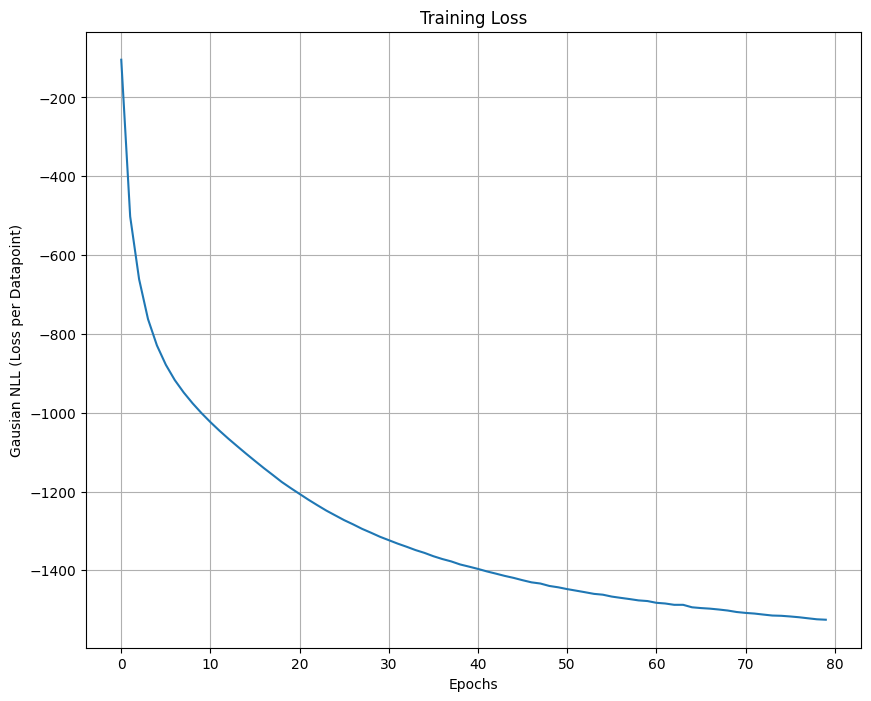

In [12]:
plt.figure(figsize=(10,8))
plt.plot(range(epochs),train_loss_history)
plt.xlabel('Epochs')
plt.ylabel('Gausian NLL (Loss per Datapoint)')
plt.title('Training Loss')
plt.grid(True)

In [13]:
test_idx = int(1e6)
available_ground_truth = dataset[test_idx:test_idx+2].reshape(-1)
available_ground_truth = available_ground_truth.astype(np.float32)
print(available_ground_truth.shape)

(400,)


In [14]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
checkpoint=torch.load("best_continuous_nade.pt",map_location=device)
model=ContinuousNADE(input_dim=400,hidden_dim=1000).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

RuntimeError: Error(s) in loading state_dict for ContinuousNADE:
	size mismatch for W: copying a param with shape torch.Size([1500, 400]) from checkpoint, the shape in current model is torch.Size([1000, 400]).
	size mismatch for c: copying a param with shape torch.Size([1500]) from checkpoint, the shape in current model is torch.Size([1000]).
	size mismatch for V_mu: copying a param with shape torch.Size([400, 1500]) from checkpoint, the shape in current model is torch.Size([400, 1000]).
	size mismatch for V_log_sigma: copying a param with shape torch.Size([400, 1500]) from checkpoint, the shape in current model is torch.Size([400, 1000]).

In [ ]:
'''
base_model = model.module if isinstance(model, nn.DataParallel) else model
base_model.eval()

generate_samples = int(5e4)
generated_time_window_samples = []

with torch.no_grad():
    for i in range(generate_samples):
        generated_time_window_samples.append(base_model.sample().cpu())
        current_count = i + 1
        if current_count % 1000 == 0:
            print(current_count, "/", generate_samples, "have been generated")
'''

In [ ]:
samples=model.sample_batch(int(4e5))
print(samples.shape)

In [ ]:
generated_time_window_samples = samples.detach().cpu().numpy().astype(np.float32)

print(generated_time_window_samples.shape)

np.save("generated_time_window_samples.npy", generated_time_window_samples)

In [ ]:
candidates = torch.from_numpy(generated_time_window_samples).float().to(device)
mu_tensor = torch.tensor(train_dataset.mean, device=candidates.device)
std_tensor = torch.tensor(train_dataset.std, device=candidates.device)
unnormalized_candidates = (candidates * std_tensor) + mu_tensor
candidate_tails = unnormalized_candidates[:, :200]
candidate_heads = unnormalized_candidates[:, 200:]

In [ ]:
forecast_horizon = int(4e4)   #Number of Sample
forecasted_trajectory = []
current_state = torch.tensor(available_ground_truth[200:], dtype=torch.float32).to(device)

In [ ]:
for i in range(forecast_horizon):
    distances = torch.norm(candidate_tails - current_state, dim=1)
    best_index = torch.argmin(distances)
    winning_forecast = candidate_heads[best_index]
    forecasted_trajectory.append(winning_forecast.cpu().numpy())
    current_state = winning_forecast

In [ ]:
forecasted_trajectory = np.array(forecasted_trajectory)
print(f"Forecasting complete! Shape: {forecasted_trajectory.shape}")

In [ ]:
data_slice=forecasted_trajectory[:1000,:]
plot_data=data_slice.T

dt=0.1
x_min,x_max=-25,25

t_start = 0
t_end = data_slice.shape[0] * dt 

plt.figure(figsize=(10,6))
plt.imshow(plot_data,
           aspect='auto',
           origin='lower',
           extent=[t_start,t_end,x_min,x_max],
           cmap='viridis',
           vmin=-2.88,
           vmax=2.88)

plt.title("Forecasted using Generative Model: NADE")
plt.xlabel("t (time units)")
plt.ylabel("x (distance along the domain)")
plt.xticks([0, 20, 40, 60, 80, 100])
plt.tight_layout()
plt.colorbar()
plt.show()

In [ ]:
sample_id = int(1e5)

plt.figure(figsize=(10,3))
plt.plot(generated_time_window_samples[sample_id, :200], label="generated tail")
plt.plot(generated_time_window_samples[sample_id, 200:], label="generated head")
plt.legend()
plt.show()

In [ ]:
# real one-step change
real_deltas = np.linalg.norm(dataset[1:10000] - dataset[:9999], axis=1)

# generated one-step change
gen_deltas = np.linalg.norm(
    generated_time_window_samples[:, 200:] - generated_time_window_samples[:, :200],
    axis=1
)

print("Real delta mean:", real_deltas.mean())
print("Generated delta mean:", gen_deltas.mean())

print("Real delta std:", real_deltas.std())
print("Generated delta std:", gen_deltas.std())

# Distribution Adherence Plots

In [ ]:
idx = int(1e6)

all_data = dataset[:]
train_data = dataset[:idx:]
truth_data = dataset[idx:idx+forecast_horizon,:]
pred_data = forecasted_trajectory[:]


In [ ]:
all_vals = np.asarray(all_data).reshape(-1)
train_vals = np.asarray(train_data).reshape(-1)
truth_vals = np.asarray(truth_data).reshape(-1)
pred_vals = np.asarray(pred_data).reshape(-1)

bins = np.linspace(
    min(all_vals.min(), train_vals.min(), truth_vals.min(), pred_vals.min()),
    max(all_vals.max(), train_vals.max(), truth_vals.max(), pred_vals.max()),
    80
)

eps = 1e-12

all_hist, edges = np.histogram(all_vals, bins=bins, density=True)
train_hist, _ = np.histogram(train_vals, bins=bins, density=True)
truth_hist, _ = np.histogram(truth_vals, bins=bins, density=True)
pred_hist, _ = np.histogram(pred_vals, bins=bins, density=True)

centers = 0.5 * (edges[:-1] + edges[1:])

all_hist = all_hist + eps
train_hist = train_hist + eps
truth_hist = truth_hist + eps
pred_hist = pred_hist + eps

left_limit = np.percentile(all_vals, 5)
right_limit = np.percentile(all_vals, 95)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Main plot
ax = axes[0]
ax.fill_between(centers, all_hist, alpha=0.35, label="All data")
ax.plot(centers, train_hist, color="black", linewidth=1.5, label="Training set")
ax.plot(centers, truth_hist, color="steelblue", linewidth=1.5, label="Truth")
ax.plot(centers, pred_hist, color="crimson", linestyle="--", linewidth=1.5, label="Prediction")
ax.set_yscale("log")
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Main Distribution")
ax.legend()

# Left tail
ax = axes[1]
ax.fill_between(centers, all_hist, alpha=0.35)
ax.plot(centers, train_hist, color="black", linewidth=1.5)
ax.plot(centers, truth_hist, color="steelblue", linewidth=1.5)
ax.plot(centers, pred_hist, color="crimson", linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlim(centers.min(), left_limit)
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Left Tail View")

# Right tail
ax = axes[2]
ax.fill_between(centers, all_hist, alpha=0.35)
ax.plot(centers, train_hist, color="black", linewidth=1.5)
ax.plot(centers, truth_hist, color="steelblue", linewidth=1.5)
ax.plot(centers, pred_hist, color="crimson", linestyle="--", linewidth=1.5)
ax.set_yscale("log")
ax.set_xlim(right_limit, centers.max())
ax.set_xlabel("State value")
ax.set_ylabel("Probability density")
ax.set_title("Right Tail View")

plt.tight_layout()
plt.show()